In [1]:
!pip install salesforce-lavis -q
!pip install faiss-gpu -q
!pip install open_clip_torch -q
!pip install deep-translator -q
!pip install -U accelerate -q

!pip uninstall transformers --yes > /dev/null 2>&1
!pip install transformers==4.42.3 -q

!pip uninstall timm --yes > /dev/null 2>&1
!pip install timm==1.0.3 -q

!pip install moviepy==1.0.3 -q
!pip install -U sentence-transformers -q
!pip install googletrans==4.0.0rc1 -q
!pip install elasticsearch -q

!git clone https://github.com/fonzi22/unilm.git > /dev/null 2>&1
!pip install -r /kaggle/working/unilm/beit3/requirements.txt -q
!wget https://github.com/addf400/files/releases/download/beit3/beit3_large_patch16_384_coco_retrieval.pth -q
!wget https://github.com/addf400/files/releases/download/beit3/beit3.spm -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.17 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.5.5.64 which is incompatible.
albumentations 1.4.17 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.5.5.64 which is incompatible.
kaggle-environments 1.14.15 requires transformers>=4.33.1, but you have transformers 4.26.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
salesforce-lavis 1.0.2 requires transformers<4.27,>=4.25.0, but you have transformers 4.42.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend

In [2]:
import sys
sys.path.append('/kaggle/input/py-lib/AIC')
sys.path.append('/kaggle/working/unilm/beit3')
import io
import torch
import sys
import os
import json
from collections import Counter, defaultdict
import numpy as np
from tqdm import tqdm
import requests
import subprocess
from PIL import Image
import cv2
import csv
import faiss
import open_clip
from lavis.models import load_model_and_preprocess
import pandas as pd
import matplotlib.pyplot as plt
import heapq
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer
from googletrans import Translator
from elasticsearch import Elasticsearch
from elastic_search_processor import ElasticSearchProcessor
import glob
import modeling_finetune
from torchvision import transforms
from torchvision.datasets.folder import default_loader
from transformers import XLMRobertaTokenizer
from timm import create_model
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD, IMAGENET_INCEPTION_MEAN, IMAGENET_INCEPTION_STD
from IPython.display import clear_output
from collections import defaultdict
import pickle
#from videollama2 import model_init, mm_infer
#from videollama2.utils import disable_torch_init

# Check for CUDA availability for optimal usage of GPU resources
# device = "cuda" if torch.cuda.is_available() else "cpu"
device0 = "cuda:0"  # First GPU for the main model
device1 = "cuda:1"  # Second GPU for CLIP and BLIP2 models


In [3]:
# Objects
OD_index_dir = "/kaggle/input/full-30l-object-index/combined_features.index"
OD_metadata_file = "/kaggle/input/full-30l-object-index/new_combined_metadata.npy"

# CLIP + BLIP2 + Beit3
clip_index_dir = "/kaggle/input/new-index/Index Final/Cosine/ViT-H14.index"
clip_metadata_file = "/kaggle/input/new-index/Index Final/Cosine/ViT-H14-metadata.npy"
blip2_index_dir = "/kaggle/input/new-index/Index Final/Cosine/AIC2024_BLIP2_features.index"
blip2_metadata_file = "/kaggle/input/new-index/Index Final/Cosine/AIC_2024_BLIP2_metadata.npy"
blip2_mat_file = "/kaggle/input/new-index/Index Final/Cosine/pca_matrix.bin"
beit3_index_dir = "/kaggle/input/new-index/Index Final/Cosine/BEIT3.index"
beit3_metadata_file = "/kaggle/input/new-index/Index Final/Cosine/BEIT3-metadata.npy"

video_dir = "/kaggle/input/aic2024-round1-data/video"
mapping_dir = "/kaggle/input/modified-csv-mapping/modified_csv_mapping"
keyframe = "/kaggle/input/new-index-final/keyframes"

In [4]:
def load_pca_matrix(file_path):
    return faiss.read_VectorTransform(file_path)

def load_metadata(file_path):
    try:
        return np.load(file_path, allow_pickle=True)
    except Exception as e:
        raise RuntimeError(f"Failed to load metadata: {e}")

def load_index(file_path):
    return faiss.read_index(file_path)

def load_models():
    model_name = 'hf-hub:laion/CLIP-ViT-H-14-laion2B-s32B-b79K'
    
    # Load OpenCLIP model and assign to second GPU (device)
    tokenizer = open_clip.get_tokenizer(model_name)
    clip_model, preprocess, _ = open_clip.create_model_and_transforms(model_name)
    clip_model = clip_model.to(device1)  # Move CLIP model to second GPU

    # Load BLIP2 model and assign to second GPU (device)
    blip2_model, blip2_vis_processors, blip2_txt_processors = load_model_and_preprocess(
        name="blip2_feature_extractor", model_type="pretrain", is_eval=True, device=device1
    )
    
    # Initialize translator and sentence transformer model
    audio_model = SentenceTransformer("multi-qa-mpnet-base-cos-v1")

    checkpoint = torch.load('/kaggle/working/beit3_large_patch16_384_coco_retrieval.pth')
    beit3_model = create_model('beit3_large_patch16_384_retrieval')
    beit3_model.load_state_dict(checkpoint['model'])
    beit3_model.eval().to(device0)
    beit3_tokenizer = XLMRobertaTokenizer('/kaggle/working/beit3.spm')
    clear_output()

    return clip_model, preprocess, tokenizer, blip2_model, blip2_vis_processors, blip2_txt_processors, audio_model, beit3_model, beit3_tokenizer


# Load CLIP + BLIP2 model
blip2_mat = load_pca_matrix(blip2_mat_file)

def load_videollama2_model():
    disable_torch_init()
    
    model_path = "DAMO-NLP-SG/VideoLLaMA2-7B-16F"
    
    # Initialize the model, processor, tokenizer
    model, processor, tokenizer = model_init(model_path)
    return model, processor, tokenizer

# Load CLIP + BLIP2 model + Objects
blip2_mat = load_pca_matrix(blip2_mat_file)
clip_metadata = load_metadata(clip_metadata_file)
blip2_metadata = load_metadata(blip2_metadata_file)
OD_metadata = load_metadata(OD_metadata_file)
beit3_metadata = load_metadata(beit3_metadata_file)

clip_index = load_index(clip_index_dir)
blip2_index = load_index(blip2_index_dir)
OD_index = load_index(OD_index_dir)
beit3_index = load_index(beit3_index_dir)

clip_model, preprocess, tokenizer, blip2_model, blip2_vis_processors, blip2_txt_processors, audio_model, beit3_model, beit3_tokenizer = load_models()


# Convert metadata to a list of dictionaries
clip_metadata = [
    {
        'video_id': item[0],  # Access the video_id
        'frame_idx': int(item[1]['frame_idx']),  # Access frame_idx and convert to integer
        'pts_time': float(item[1]['pts_time']),  # Access pts_time and convert to float
        'score': 0  # Initialize score
    }
    for item in clip_metadata
]

blip2_metadata = [
    {
        'video_id': item[0],  # Access the video_id
        'frame_idx': int(item[1]['frame_idx']),  # Access frame_idx and convert to integer
        'pts_time': float(item[1]['pts_time']),  # Access pts_time and convert to float
        'score': 0  # Initialize score
    }
    for item in blip2_metadata
]

beit3_metadata = [
    {
        'video_id': item[0],  # Access the video_id
        'frame_idx': int(item[1]['frame_idx']),  # Access frame_idx and convert to integer
        'pts_time': float(item[1]['pts_time']),  # Access pts_time and convert to float
        'score': 0  # Initialize score
    }
    for item in beit3_metadata
]

In [5]:
es_processor = ElasticSearchProcessor(
    "https://6ff20889decc43ccb66b9cfaff11fde9.asia-east1.gcp.elastic-cloud.com:443", 
    "MEstQmhwSUI0MFU0bGhMbU0taU86dzdQZE9tNm9TeGlLYUoxY0VERkRzQQ==", 
    "video_frames"
)

success, message = es_processor.create_index_with_mapping()
print(message)
es_processor.client.ping()

Index 'video_frames' đã tồn tại


True

In [6]:
def beit3_get_text_segment(text, tokenizer, max_len = 64):
    tokens = tokenizer.tokenize(text)
    tokens = tokenizer.convert_tokens_to_ids(tokens)
    if len(tokens) > max_len -2:
        tokens = tokens[:max_len-2]
    tokens = [tokenizer.bos_token_id] + tokens[:] + [tokenizer.eos_token_id]
    num_tokens = len(tokens)
    padding_mask = [0] * num_tokens + [1] * (max_len - num_tokens)
    language_tokens = tokens + [tokenizer.pad_token_id] * (max_len - num_tokens)
    return torch.tensor([language_tokens]),  torch.tensor([padding_mask]), num_tokens
    
def encode_text_query_beit3(query, model, tokenizer):
    language_tokens, padding_mask, _ = beit3_get_text_segment(query, tokenizer)
    language_tokens = language_tokens.to(device0)
    padding_mask = padding_mask.to(device0)
    _, language_cls = model(text_description=language_tokens, padding_mask=padding_mask, only_infer=True)
    '''
    text = tokenizer([query]).to(device0)
    with torch.no_grad():
        text_features = model.encode_text(text).squeeze().cpu().numpy()
    return text_features'''
    result = language_cls.detach().cpu().numpy()
    return result

def encode_text_query_clip(query, model, tokenizer):
    text = tokenizer([query]).to(device1)
    with torch.no_grad():
        text_features = model.encode_text(text).squeeze().cpu().numpy()
        text_features /= np.linalg.norm(text_features, axis=0, keepdims=True)
    del text
    torch.cuda.empty_cache() 
    return text_features

def encode_text_query_blip2(query, model, txt_processors):
    text_input = txt_processors["eval"](query)
    sample = {"image": np.zeros((100, 100, 3), dtype=np.uint8), "text_input": [text_input]}
    with torch.no_grad():
        text_features = model.extract_features(sample, mode="text")
        text_features = text_features.text_embeds_proj[:, 0, :].cpu().numpy()
        text_features = text_features.reshape(1, -1).astype('float32')  
        text_features /= np.linalg.norm(text_features, axis=1, keepdims=True)
        expanded_text_features = np.tile(text_features, 32)
    text_features_reduced = blip2_mat.apply_py(expanded_text_features).astype('float32')
    del text_input, sample, text_features, expanded_text_features
    torch.cuda.empty_cache()
    return text_features_reduced

def encode_text_query_audio(query):
    feature_vector = np.array(audio_model.encode(query))
    feature_vector = feature_vector[np.newaxis, :]
    feature_vector = feature_vector / np.linalg.norm(feature_vector)  # Normalize the vector
    return feature_vector

def clip_encode_image_query(image, model, preprocess):
    image = Image.open(image).convert("RGB")
    image = preprocess(image).unsqueeze(0).to(device1)
    with torch.no_grad():
        image_features = model.encode_image(image).squeeze().cpu().numpy()
    del image 
    torch.cuda.empty_cache()
    return image_features

def blip2_encode_image_query(image, model, vis_processors):
    image = Image.open(image).convert("RGB")
    image = vis_processors['eval'](image).unsqueeze(0).to(device1)
    with torch.no_grad():
        image_features = model.extract_features({"image": image}, mode="image")
        flattened_features = image_features.image_embeds_proj.view(1, -1).cpu().numpy()
        image_features = blip2_mat.apply_py(flattened_features).astype('float32')
    del image, flattened_features  
    torch.cuda.empty_cache()  
    return image_features

# Combine features and searching
def combine_features(text_features, image_features, text_weight=0.6, image_weight=0.4):
    text_features /= np.linalg.norm(text_features, axis=0, keepdims=True)
    image_features /= np.linalg.norm(image_features, axis=0, keepdims=True)
    combined_features = text_weight * text_features + image_weight * image_features
    combined_features /= np.linalg.norm(combined_features, axis=0, keepdims=True)
    return combined_features

def search_index(index, query_features, metadata, k=100):
    query_features = np.array(query_features).reshape(1, -1).astype('float32')
    distances, indices = index.search(query_features, k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        try:
            video_id, frame_info = metadata[idx]['video_id'], metadata[idx]
            frame_idx = int(frame_info['frame_idx'])
            timestamp = float(frame_info['pts_time'])
            results.append({'video_id': video_id, 'frame_idx': frame_idx, 'pts_time': timestamp, 'score': dist})
        except IndexError:
            continue
    results.sort(key=lambda x: x['score'], reverse=True)
    return results


def search_audio_knn(input_keyword, es_processor, indices=['audio_features_1', 'audio_features_2', 'audio_features_3', 'audio_features_4'], k=10):
    # Encode the input keyword
    vector = encode_text_query_audio(input_keyword)
    
    # Initialize the results list
    all_results = []
    
    # Iterate over the indices and perform the search for each one
    for index_name in indices:
        # Get the document count for the current index
        doc_count = es_processor.client.count(index=index_name)['count']
        
        # KNN search query for the current index
        knn_query = {
            "field": "AudioTextVector",
            "query_vector": vector.flatten().tolist(),  # Ensure it's a list for Elasticsearch
            "k": k,  # Return top k results
            "num_candidates": doc_count
        }
        
        # Perform the search
        res = es_processor.client.knn_search(index=index_name, knn=knn_query, _source=["video_id", "start_time", "end_time"])
        
        # Output and collect the search results
        for hit in res["hits"]["hits"]:
            result = {
                'video_id': hit['_source']['video_id'],
                'start_time': hit['_source']['start_time'],
                'end_time': hit['_source']['end_time'],
                'score': hit['_score']  # Store similarity score for sorting
            }
            all_results.append(result)
    
    # Sort all results by their similarity score (higher score = better match)
    all_results = sorted(all_results, key=lambda x: x['score'], reverse=True)
    
    # Return all results sorted by similarity score
    return all_results

def search_ocr(query, es_processor, index='ocr_features_first', size=50):
    # Get the document count for the specified index
    doc_count = es_processor.client.count(index=index)['count']
    
    # Construct the Elasticsearch query for text match in OCRText field
    query_text = {
        "size": size,  # Return top `size` results
        "query": {
            "match": {
                "OCRText": query  # Search for the query text in OCRText field
            }
        }
    }
    
    # Perform the search on the specified index
    res = es_processor.client.search(index=index, body=query_text, _source=["video_id", "pts_time", "frame_idx", "OCRText"])
    
    # Initialize results list
    results = []
    
    # Process and collect the search results
    for hit in res["hits"]["hits"]:
        result = {
            'video_id': hit['_source']['video_id'],
            'pts_time': hit['_source']['pts_time'],
            'frame_idx': hit['_source']['frame_idx'],
            'ocr_text': hit['_source']['OCRText']
        }
        results.append(result)
    
    # Return all results
    return results


# Function to read CSV mapping files
def load_frame_mappings(video_id):
    csv_file = os.path.join(mapping_dir, f"{video_id}.csv")
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"Mapping file for video ID {video_id} not found.")
    df = pd.read_csv(csv_file)
    # Map frame_idx as key to n as value
    return pd.Series(df.n.values, df.frame_idx.values).to_dict()

def extract_frame_at_keyframe(video_id, keyframe_idx):
    """Extract the keyframe from the specified path."""
    # Ensure the keyframe index is formatted to retain only the last four digits
    formatted_idx = f"{keyframe_idx % 10000:04d}"  # Format to four digits with leading zeros

    # Construct the path for both keyframe folders
    keyframe_path = os.path.join(keyframe, video_id, f"{formatted_idx}.jpg")

    # Check the first keyframe folder
    if os.path.exists(keyframe_path):
        return Image.open(keyframe_path)  # Use PIL Image to open the file
    else:
        print(f"Keyframe not found for Video ID {video_id} at index {formatted_idx}.")
        return None
    
def get_ms_time(video_id, frame_idx):
    csv_file = os.path.join(mapping_dir, f"{video_id}.csv")
    
    # Check if the CSV file exists
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"Mapping file for video ID {video_id} not found.")
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_file)
    
    # Check if both 'ms_time' and 'frame_idx' columns exist
    if 'ms_time' not in df.columns or 'frame_idx' not in df.columns:
        raise ValueError(f"Required columns not found in {video_id}.csv")
    
    # Filter the DataFrame for the specific frame_idx
    ms_time_row = df[df['frame_idx'] == frame_idx]
    
    # Check if the frame index exists in the CSV
    if ms_time_row.empty:
        raise ValueError(f"Frame index {frame_idx} not found in {video_id}.csv")
    
    # Return the ms_time for the specific frame index
    return ms_time_row['ms_time'].values[0]

In [7]:
# Tạo một danh sách để lưu tên video và FPS
fps_data = []

# Thư mục chứa video
video_directory = "/kaggle/input/aic2024-round1-data/video"

# Lấy danh sách các file video trong thư mục
video_files = [f for f in os.listdir(video_directory) if f.endswith('.mp4')]

# Duyệt qua từng video và lấy FPS
for video_filename in video_files:
    video_path = os.path.join(video_directory, video_filename)
    video = cv2.VideoCapture(video_path)
    fps = int(video.get(cv2.CAP_PROP_FPS))  # Chuyển FPS sang số nguyên
    
    # Bỏ đuôi .mp4 từ tên video
    video_name = video_filename.rsplit('.mp4', 1)[0]
    
    # Thêm thông tin video và FPS vào danh sách
    fps_data.append({"Video Filename": video_name, "FPS": fps})

# Chuyển dữ liệu sang DataFrame để dễ quản lý
fps_df = pd.DataFrame(fps_data)

# Lưu DataFrame ra file CSV nếu cần
fps_df.to_csv("fps_data.csv", index=False)

# Hiển thị DataFrame
print(fps_df)

def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Hàm lấy FPS của video từ tên
def get_fps(video_name):
    fps_row = fps_df[fps_df["Video Filename"] == video_name]
    if not fps_row.empty:
        return int(fps_row["FPS"].values[0])
    return None

# Hàm tính toán chỉ số frame tương ứng với thời gian mm:ss
def get_frame_number(video_filename, time_str):
    # Lấy FPS từ DataFrame
    fps = get_fps(video_filename)
    
    if fps is None:
        print(f"Không tìm thấy FPS cho video {video_filename}")
        return None
    
    # Chuyển thời gian sang giây
    time_in_seconds = time_to_seconds(time_str)
    
    # Tính toán frame tương ứng
    frame_number = int(fps * time_in_seconds)
    
    return frame_number

    Video Filename  FPS
0         L24_V002   25
1         L05_V015   25
2         L14_V027   25
3         L15_V012   30
4         L20_V030   30
..             ...  ...
721       L01_V030   25
722       L05_V003   25
723       L18_V025   30
724       L08_V009   25
725       L16_V023   30

[726 rows x 2 columns]


# Final Re-rank

In [14]:
def FinalReRank(results_blip2, results_clip, results_beit3, combined_audio_results, OCR_result, results_OD, weights=(0.2, 0.2, 0.6), k=100, boost_factor=1.1, boost_window=180):
    combined_scores = {}
    details = {}
    constant = 20

    # ----- Debug tracking for specific videos -----
    target_videos = []
    
    def debug_print(video_id, frame_idx, score, stage):
        if video_id in target_videos:
            print(f"[DEBUG] {stage} - Video: {video_id}, Frame: {frame_idx}, Score: {score}")

    # Function to calculate weighted RRF
    def calculate_weighted_rrf(ranks, k=60):
        combined_scores = {}
        for key, rank_list in ranks.items():
            rrf_score = sum(weight * (1 / (rank + k)) for rank, weight in rank_list)
            combined_scores[key] = rrf_score
        return combined_scores

    # Store ranks for RRF, keeping track of weights for each rank
    ranks = {}

    # Process BLIP2 results
    for rank, result in enumerate(results_blip2, start=1):
        key = (result['video_id'], result['frame_idx'])
        if key not in ranks:
            ranks[key] = []
        # Append rank and corresponding weight for BLIP2
        ranks[key].append((rank, weights[0]))

        # Populate details
        details[key] = result['pts_time']

        # Debugging output
        debug_print(result['video_id'], result['frame_idx'], rank, "BLIP2")

    # Process CLIP results
    for rank, result in enumerate(results_clip, start=1):
        key = (result['video_id'], result['frame_idx'])
        if key not in ranks:
            ranks[key] = []
        # Append rank and corresponding weight for CLIP
        ranks[key].append((rank, weights[1]))

        # Populate details
        details[key] = result['pts_time']

        # Debugging output
        debug_print(result['video_id'], result['frame_idx'], rank, "CLIP")

    # Process Beit3 results
    for rank, result in enumerate(results_beit3, start=1):
        key = (result['video_id'], result['frame_idx'])
        if key not in ranks:
            ranks[key] = []
        # Append rank and corresponding weight for Beit3
        ranks[key].append((rank, weights[2]))

        # Populate details
        details[key] = result['pts_time']

        # Debugging output
        debug_print(result['video_id'], result['frame_idx'], rank, "Beit3")

    # Calculate weighted RRF scores
    combined_scores = calculate_weighted_rrf(ranks)

    # ----- ASR boost -----
    max_audio_score = max([audio_result['score'] for audio_result in combined_audio_results]) if combined_audio_results else 1

    for result in combined_scores.items():
        (video_id, frame_idx), score = result
        for audio_result in combined_audio_results:
            if video_id == audio_result['video_id'] and details.get((video_id, frame_idx), 0) >= audio_result['start_time'] and details.get((video_id, frame_idx), 0) <= audio_result['end_time']:
                normalized_audio_score = audio_result['score'] / max_audio_score
                combined_scores[(video_id, frame_idx)] += normalized_audio_score
                debug_print(video_id, frame_idx, combined_scores[(video_id, frame_idx)], "ASR Boost")

    # ----- OD boost -----
    for od_result in results_OD:
        od_video_id = od_result['video_id']
        od_frame_idx = od_result['frame_idx']
        od_score = od_result['score']
        
        for existing_key in combined_scores:
            if existing_key[0] == od_video_id and abs(existing_key[1] - od_frame_idx) <= boost_window:
                combined_scores[existing_key] += od_score * boost_factor
                debug_print(existing_key[0], existing_key[1], combined_scores[existing_key], "OD Boost")

    # Sort combined results by score
    combined_results = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

    # Return the top k results
    final_results = []
    for (video_id, frame_idx), score in combined_results[:k]:
        frame_mapping = load_frame_mappings(video_id)
        keyframe_idx = frame_mapping.get(frame_idx)  # Use get to avoid KeyError
        if keyframe_idx is not None:
            frame = extract_frame_at_keyframe(video_id, keyframe_idx)
            pts_time = details.get((video_id, frame_idx))  # Use get to avoid KeyError
            if pts_time is not None:  # Check if pts_time is valid
                final_results.append({
                    'video_id': video_id,
                    'frame_idx': frame_idx,
                    'pts_time': pts_time,
                    'score': score,
                    'frame': frame
                })

    # Final debug output for tracked videos
    for result in final_results:
        if result['video_id'] in target_videos:
            print(f"[DEBUG] Final result - Video: {result['video_id']}, Frame: {result['frame_idx']}, Score: {result['score']}, Time: {result['pts_time']}")

    return final_results



# Temporal Search Algorithm
def temporal_search_algorithm(A, B, C, w_a=1, w_c=1):
    for bi in B:
        video_id = bi['video_id']
        
        A1 = [ai for ai in A if ai['video_id'] == video_id]
        C1 = [ci for ci in C if ci['video_id'] == video_id]
        
        # Apply weights to scores
        ai_score = max((ai['score'] for ai in A1), default=0) * w_a
        ci_score = max((ci['score'] for ci in C1), default=0) * w_c
        
        # Add the scores to the main query result
        bi['score'] = bi['score'] + ai_score + ci_score
    
    # Sort B by the weighted score in descending order
    B_sorted = sorted(B, key=lambda x: x['score'], reverse=True)
    
    return B_sorted


def process_queries(query_a, query_b, query_c, OCR_query, OD_query, ASR_query, 
                    text_weight=1, image_weight=0, weights=(0.2, 0.2, 0.6), image=None, negative_query=None, blacklist=None,
                    query_a_weight=1, query_c_weight=1):
    
    # Initialize blacklist if not provided
    if blacklist is None:
        blacklist = []  # List of video IDs that should be excluded

    # Initialize OCR_result to ensure it has a default value
    OCR_result = []  # or None, depending on how you want to handle it

    def perform_search(query):
        """Regular search logic."""
        if query:
            # Encode the query using both CLIP and BLIP2 models
            query_features_clip = encode_text_query_clip(query, clip_model, tokenizer)
            query_features_blip2 = encode_text_query_blip2(query, blip2_model, blip2_txt_processors)
            query_features_beit3 = encode_text_query_beit3(query, beit3_model, beit3_tokenizer)
            
            # Process image query only if an image is provided
            clip_image_features = None
            blip2_image_features = None
            if image is not None:
                clip_image_features = clip_encode_image_query(image, clip_model, preprocess)
                blip2_image_features = blip2_encode_image_query(image, blip2_model, blip2_vis_processors)
            
            # Use only text features if no image is provided
            if clip_image_features is None or blip2_image_features is None:
                clip_combine_features = query_features_clip
                blip2_combine_features = query_features_blip2
            else:
                # Combine image features if available
                clip_combine_features = combine_features(query_features_clip, clip_image_features, text_weight, image_weight)
                blip2_combine_features = combine_features(query_features_blip2, blip2_image_features, text_weight, image_weight)
            
            beit3_combine_features = query_features_beit3

            # Search in both indexes
            results_clip = search_index(clip_index, clip_combine_features, clip_metadata, k=250)
            results_blip2 = search_index(blip2_index, blip2_combine_features, blip2_metadata, k=250)
            results_beit3 = search_index(beit3_index, beit3_combine_features, beit3_metadata, k=250)
            
        
            return results_clip, results_blip2, results_beit3
        else:
            return [], [], []
        
    def adjust_scores_with_negative_results(main_results, negative_results):
        """Decreases scores of overlapping results between main and negative search results."""
        main_results_dict = {result['video_id']: result for result in main_results}
        for neg_result in negative_results:
            video_id = neg_result['video_id']
            if video_id in main_results_dict:
                main_results_dict[video_id]['score'] -= 1.0  # Example: Decrease score by 1.0
                if main_results_dict[video_id]['score'] < 0:
                    main_results_dict[video_id]['score'] = 0
        return list(main_results_dict.values())

    def apply_blacklist_filtering(results, blacklist):
        """Remove results that fall within blacklisted frame ranges for each video."""
        if (blacklist == None):
            return results
        
        filtered_results = []

        for result in results:
            video_id = result['video_id']
            frame_idx = result['frame_idx']

            # Check if this video is in the blacklist
            if video_id in blacklist:
                # Get the list of frame ranges/indices for this video
                blacklisted_frames = blacklist[video_id]

                # Filter out the result if it falls within any range or matches a specific frame
                to_filter = False
                for entry in blacklisted_frames:
                    if isinstance(entry, tuple):
                        # Entry is a range (e.g., (1000, 1500))
                        if entry[0] <= frame_idx <= entry[1]:
                            to_filter = True
                            break
                    else:
                        # Entry is a specific frame index (e.g., 1300)
                        if frame_idx == entry:
                            to_filter = True
                            break

                if not to_filter:
                    filtered_results.append(result)
            else:
                # If the video is not in the blacklist, keep the result
                filtered_results.append(result)

        return filtered_results
    
    def remove_near_duplicates(results, proximity_threshold=100):
        """Keep only unique frames that are far enough apart from each other within the same video."""
        filtered_results = []
        last_frame_idx_per_video = {}  # Dictionary to track the last added frame index per video

        for result in results:
            video_id, frame_idx = result['video_id'], result['frame_idx']

            # Check if this video has been encountered before
            if video_id not in last_frame_idx_per_video:
                last_frame_idx_per_video[video_id] = -proximity_threshold  # Initialize for new video

            # Only add result if it is far enough from the last added frame of the same video
            if abs(frame_idx - last_frame_idx_per_video[video_id]) > proximity_threshold:
                filtered_results.append(result)
                last_frame_idx_per_video[video_id] = frame_idx  # Update the last added frame index for this video

        return filtered_results


    # Perform searches for non-empty queries
    A_clip, A_blip2, A_beit3 = perform_search(query_a) if query_a else ([], [], [])
    B_clip, B_blip2, B_beit3 = perform_search(query_b) if query_b else ([], [], [])
    C_clip, C_blip2, C_beit3 = perform_search(query_c) if query_c else ([], [], [])

    # If B (main query) is empty, we can't proceed
    if not B_clip and not B_blip2:
        return []

    # Combine the results from CLIP and BLIP2 for the main query B
    combined_clip_results = temporal_search_algorithm(A_clip, B_clip, C_clip, query_a_weight, query_c_weight)
    combined_blip2_results = temporal_search_algorithm(A_blip2, B_blip2, C_blip2, query_a_weight, query_c_weight)
    combined_beit3_results = temporal_search_algorithm(A_beit3, B_beit3, C_beit3, query_a_weight, query_c_weight)
    
    # Perform the negative search if provided
    if negative_query:
        neg_clip, neg_blip2, neg_beit3, neg_audio = perform_search(negative_query)
        combined_clip_results = adjust_scores_with_negative_results(combined_clip_results, neg_clip)
        combined_blip2_results = adjust_scores_with_negative_results(combined_blip2_results, neg_blip2)
        combined_beit3_results = adjust_scores_with_negative_results(combined_beit3_results, neg_beit3)

    # Apply blacklist filtering to remove unwanted video IDs
    combined_clip_results = apply_blacklist_filtering(combined_clip_results, blacklist)
    combined_blip2_results = apply_blacklist_filtering(combined_blip2_results, blacklist)
    combined_beit3_results = apply_blacklist_filtering(combined_beit3_results, blacklist)

    results_audio = []
    results_OD = []
    OCR_result = []
    
    # ASR Elastic Search
    if ASR_query is not None:
        results_audio = search_audio_knn(ASR_query, es_processor, k=10)
    
    # OD search
    if OD_query is not None:
        OD_query_features = encode_text_query_clip(OD_query, clip_model, tokenizer)
        results_OD = search_index(clip_index, OD_query_features, OD_metadata, k=20)
    
    # OCR Elastic Search
    if OCR_query is not None:
        OCR_result = search_ocr(OCR_query, es_processor, index='ocr_features_first', size=30)
    
    # Apply Reciprocal Rank Fusion (RRF) to combine results
    final_results = FinalReRank(combined_blip2_results, combined_clip_results, combined_beit3_results, results_audio, OCR_result, results_OD, weights=(0.2, 0.3, 0.6), k=100)
    
    # Apply remove_near_duplicates
    final_results = remove_near_duplicates(final_results)

    return final_results


def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes:02}:{seconds:02}"

def extract_frame_at_time(video_path, time):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_idx = int(fps * time)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame, frame_idx if ret else (None, None)

def print_dataframe(data):
    data_for_csv = [[str(row[0]), row[1]] for row in data]
    df = pd.DataFrame(data_for_csv, columns=['Video_ID', 'Frame'])
    st.write("DataFrame:")
    st.dataframe(df)
    return df

In [15]:
import os
import sqlite3
import subprocess
import re
from IPython.display import display, Markdown
from IPython.display import Video

# Function to clear the directory
def clear_directory(directory_path):
    """Clear the contents of a directory."""
    if os.path.exists(directory_path):
        for file in os.listdir(directory_path):
            file_path = os.path.join(directory_path, file)
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                os.rmdir(file_path)
    else:
        os.makedirs(directory_path)

# Display frames with metadata and YouTube links
def display_frames(frames_list, db_file):
    """Display frames in an organized way with metadata and YouTube links from the database."""
    if not frames_list:
        print("No frames to display.")
        return
    
    conn = sqlite3.connect(db_file)  # Connect to the database
    cursor = conn.cursor()

    for frame, video_id, frame_idx, frame_image_path, pts_time, ms_time in frames_list:
        plt.figure(figsize=(8, 10))
        plt.imshow(frame)
        plt.title(f"Video ID: {video_id}\nFrame ID: {frame_idx}\nPTS Time: {format_time(pts_time)}\nTime: {int(ms_time)}", fontsize=12)
        plt.axis('off')
        plt.show()

        # Query database for YouTube link
        cursor.execute('SELECT * FROM Videos WHERE video_id = ?', (video_id,))
        row = cursor.fetchone()

        if row:
            url = row[3]  # Assuming the URL is in the fourth column
            match = re.search(r"(?<=v=)[\w-]+", url)
            if match:
                youtube_id = match.group(0)
                youtube_url = f"https://www.youtube.com/watch?v={youtube_id}&t={int(pts_time)}s"
                display(Markdown(f"[Watch on YouTube]({youtube_url})"))
                print(f""""mediaItemName": "{video_id}", "start": {round(ms_time)}, "end": {round(ms_time)}""")
                print(f"x-{video_id}-{round(ms_time)}")
        else:
            print(f"Video ID {video_id} not found in the database.")

    conn.close()  # Close the database connection

# Process results and display
def process_results(results, db_file, output_dir="output", start_index=0, end_index=100):
    """Process results to extract, save, and display frames with YouTube links from the database."""
    clear_directory(output_dir)
    results = results[start_index:end_index]
    
    frames_list = []
    
    for i, result in enumerate(results):
        video_id = result['video_id']
        pts_time = result['pts_time']
        frame_idx = result['frame_idx']
        frame = result['frame']
        ms_time = get_ms_time(video_id, frame_idx)
        frame_image_path = os.path.join(output_dir, f"{video_id}_{frame_idx}.jpg")
        
        if frame is not None:
            frames_list.append((frame, video_id, frame_idx, frame_image_path, pts_time, ms_time))
            # Display frame and YouTube link immediately after 
            display_frames([frames_list[-1]], db_file)

# Convert seconds into hh:mm:ss format for ffmpeg
def format_time_ffmpeg(seconds):
    """Convert seconds into hh:mm:ss format for ffmpeg."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f"{hours:02}:{minutes:02}:{seconds:02}"

# Convert seconds into hh:mm:ss format for display
def format_time(seconds):
    """Convert seconds into hh:mm:ss format for display."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f"{hours:02}:{minutes:02}:{seconds:02}"
        
def play_video_segment(video_path, target_time, window_seconds=20, output_dir="output"):
    """
    Play a video segment around a specific frame time with a ±window_seconds window.
    
    Parameters:
        video_path (str): Path to the input video file.
        target_time (float): Time in seconds of the specific frame.
        window_seconds (int): Number of seconds before and after the target time to include in the video segment.
        output_dir (str): Directory to save the extracted video segment.
    """
    # Ensure the output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Define the start and end times for the segment
    start_time = max(0, target_time - window_seconds)
    end_time = target_time + window_seconds
    duration = end_time - start_time
    
    # Define the output video path
    output_video_path = os.path.join(output_dir, "segment.mp4")
    
    # Delete the output file if it already exists
    if os.path.exists(output_video_path):
        os.remove(output_video_path)
    
    # Construct the ffmpeg command to extract the video segment
    command = [
        "ffmpeg",
        "-i", video_path,
        "-ss", str(start_time),
        "-t", str(duration),
        "-c:v", "copy",
        "-c:a", "copy",
        "-y",  # Overwrite output file without prompting
        output_video_path
    ]
    
    # Debug: Print the command
    print("Running command:", " ".join(command))
    
    # Run the ffmpeg command
    try:
        result = subprocess.run(command, check=True, text=True, capture_output=True)
        print("FFmpeg output:", result.stdout)
    except subprocess.CalledProcessError as e:
        print(f"Error: {e}")
        print("FFmpeg stderr:", e.stderr)
        return None
    
    # Display the extracted video segment
    if os.path.exists(output_video_path):
        return output_video_path
    else:
        print("Error: Could not extract video segment.")
        return None

# Translation

In [16]:
from deep_translator import GoogleTranslator

# Text to translate
text_to_translate = "Bread, cookies in batskets"

# Translate from English to Vietnamese
translation = GoogleTranslator(source='vi', target='en').translate(text_to_translate)

# Print the result
print(f"Original text: {text_to_translate}")
print(f"Translated text: {translation}")


Original text: Bread, cookies in batskets
Translated text: Bread, cookies in batskets


# Search

In [17]:
"""
blacklist = {
    'video_id_1': [101, 102],
    'video_id_2': [(200, 300)],   
}

"""

query_a = ""

query_b = "Scene from an exhibition area. There are two objects that look like jars, on the left side closest to the camera. Next there is a person looking at a clock with a clock face in front and a small tower-like model on top. Next is a scene of paintings placed in golden frames. From left to right are rectangular, elliptical and elliptical frames respectively."

query_c = ""

query_a_weight = 0.5 

query_c_weight = 0.5

clip_weight = 0.2

blip2_weight = 0.2

beit3_weight = 0.6

image = None

text_weight = 1

image_weight = 0

negative_query = None

blacklist = None

OCR_query = None

OD_query = None

ASR_query = None

In [18]:
results = process_queries(query_a, query_b, query_c, OCR_query, OD_query, ASR_query, text_weight, image_weight, (blip2_weight, clip_weight, beit3_weight), image, negative_query, blacklist, query_a_weight, query_c_weight)

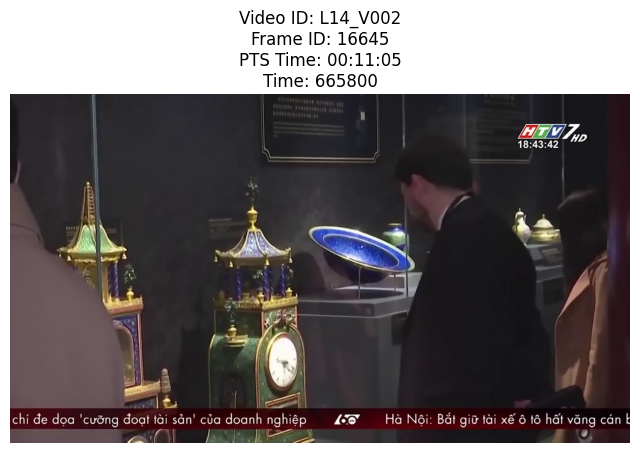

[Watch on YouTube](https://www.youtube.com/watch?v=Ier3tiTGAHs&t=665s)

"mediaItemName": "L14_V002", "start": 665800, "end": 665800
x-L14_V002-665800


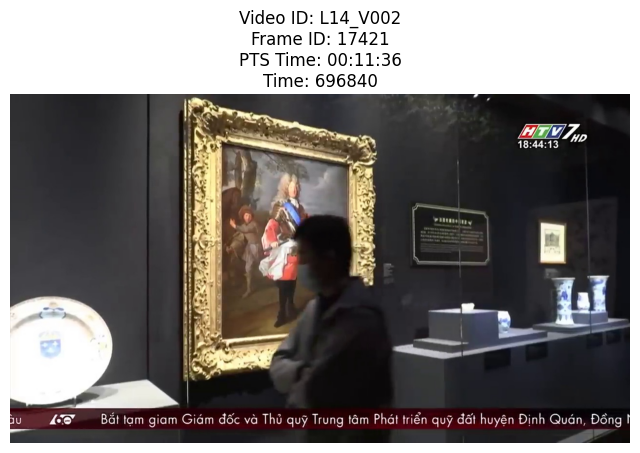

[Watch on YouTube](https://www.youtube.com/watch?v=Ier3tiTGAHs&t=696s)

"mediaItemName": "L14_V002", "start": 696840, "end": 696840
x-L14_V002-696840


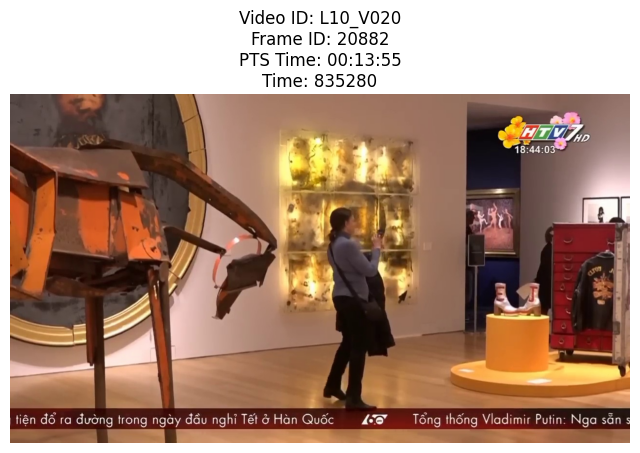

[Watch on YouTube](https://www.youtube.com/watch?v=JBs2UjKaAaE&t=835s)

"mediaItemName": "L10_V020", "start": 835280, "end": 835280
x-L10_V020-835280


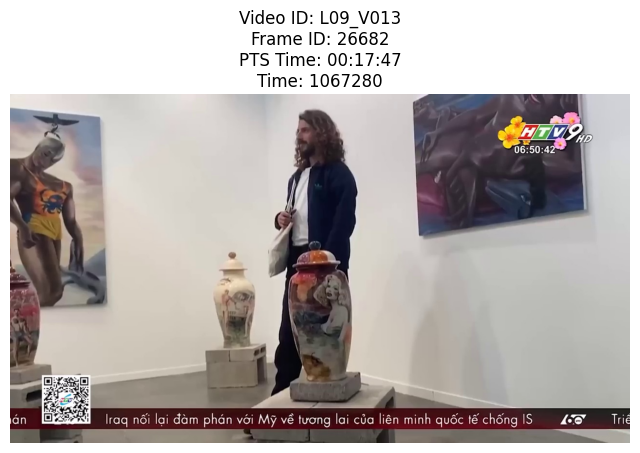

[Watch on YouTube](https://www.youtube.com/watch?v=cWIe53AMONM&t=1067s)

"mediaItemName": "L09_V013", "start": 1067280, "end": 1067280
x-L09_V013-1067280


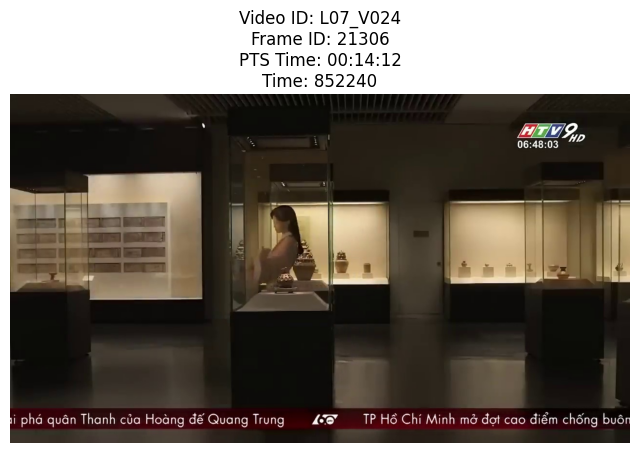

[Watch on YouTube](https://www.youtube.com/watch?v=6nUmojimPZE&t=852s)

"mediaItemName": "L07_V024", "start": 852240, "end": 852240
x-L07_V024-852240


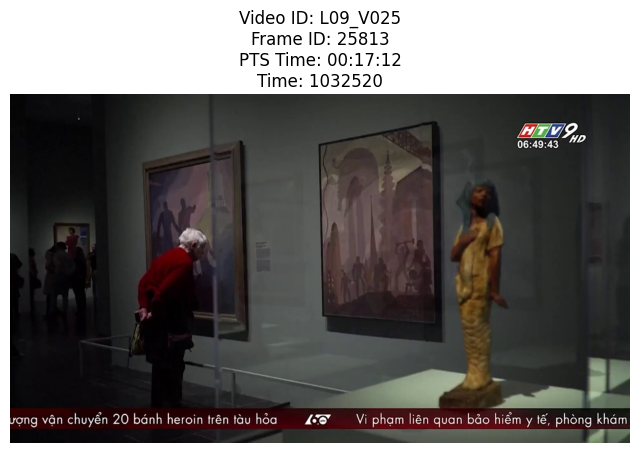

[Watch on YouTube](https://www.youtube.com/watch?v=MBcbcnjT8HE&t=1032s)

"mediaItemName": "L09_V025", "start": 1032520, "end": 1032520
x-L09_V025-1032520


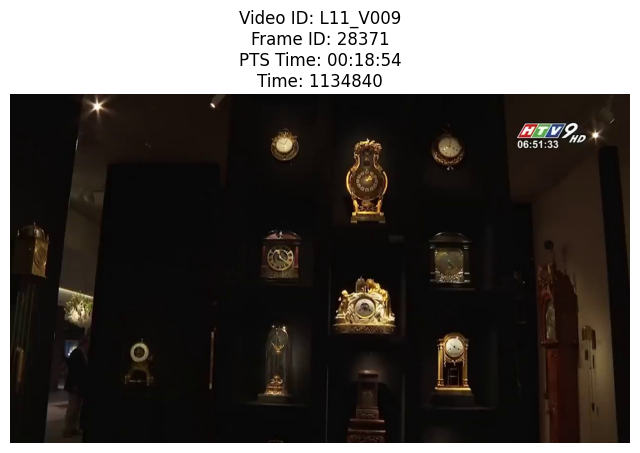

[Watch on YouTube](https://www.youtube.com/watch?v=UK8gVojvwwk&t=1134s)

"mediaItemName": "L11_V009", "start": 1134840, "end": 1134840
x-L11_V009-1134840


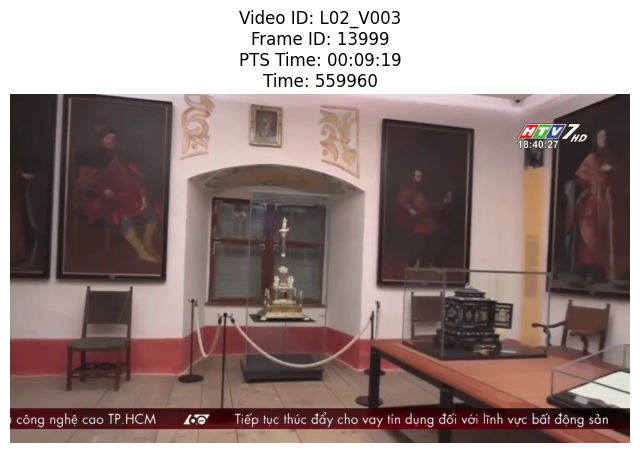

[Watch on YouTube](https://www.youtube.com/watch?v=m7hc_dNufeE&t=559s)

"mediaItemName": "L02_V003", "start": 559960, "end": 559960
x-L02_V003-559960


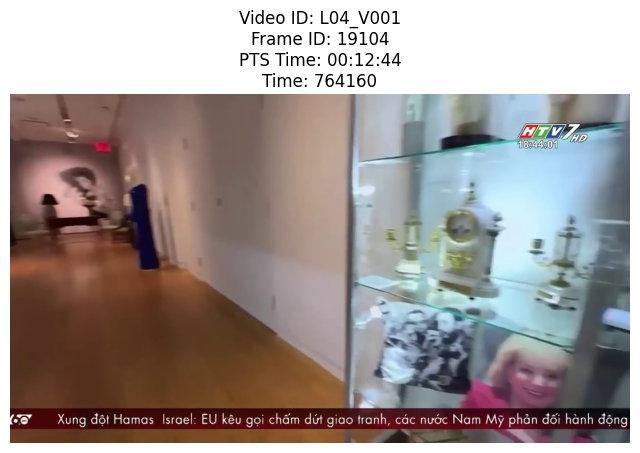

[Watch on YouTube](https://www.youtube.com/watch?v=aJLgbg8X1GY&t=764s)

"mediaItemName": "L04_V001", "start": 764160, "end": 764160
x-L04_V001-764160


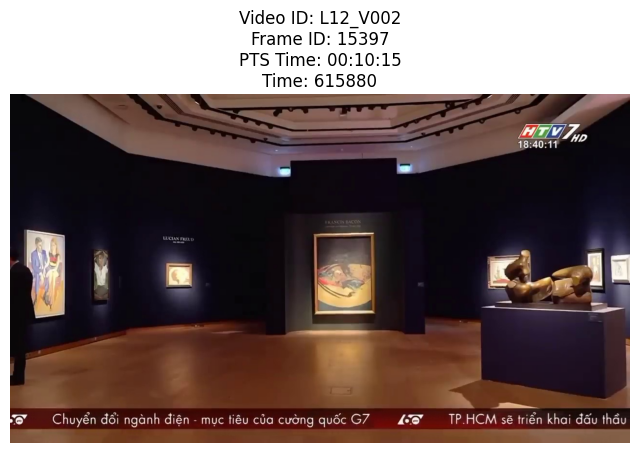

[Watch on YouTube](https://www.youtube.com/watch?v=vmyQ2JYlgCs&t=615s)

KeyboardInterrupt: 

In [19]:
# Directory to save the output
output_dir = '/kaggle/working/frames_results'
db_file = '/kaggle/input/metadata-new/video_metadata.db'

# Extract and display the frame and video segment for each result
process_results(results, db_file, output_dir, 0, 50)